In [ ]:
from tensorflow import keras
from keras.layers import Input, Dense
from keras.models import Model
from keras.datasets import mnist
import numpy as np

In [1]:
import tensorflow as tf

In [ ]:
print(tf.__version__)

In [ ]:
(x_train, _), (x_test, _) = mnist.load_data()

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

n = 10  # how many records we will display
plt.figure(figsize=(20, 4))

for i in range(n):
    ax = plt.subplot(1, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

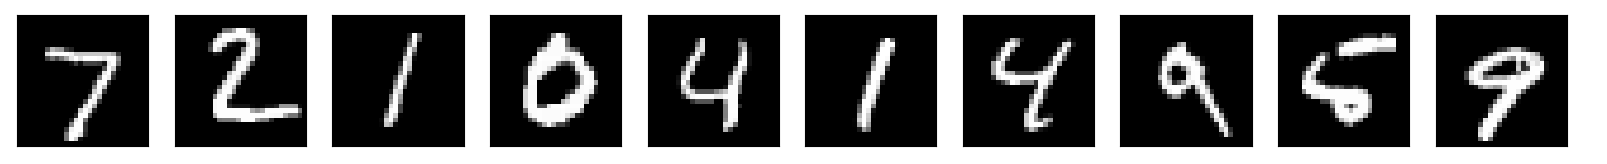

In [4]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, UpSampling2D, Reshape

In [5]:
encode_model = Sequential()

############
# Encoding #
############

# FIRST SET OF LAYERS
encode_model.add(Conv2D(filters=16, kernel_size=(3, 3), input_shape=(28, 28, 1),
                        activation='relu', padding='same'))
encode_model.add(MaxPool2D(pool_size=(2, 2), padding='same'))

# SECOND SET OF LAYERS
encode_model.add(Conv2D(filters=8, kernel_size=(3, 3), activation='relu', padding='same'))
encode_model.add(MaxPool2D(pool_size=(2, 2), padding='same'))

# BOTTLENECK
encode_model.add(Flatten())
encode_model.add(Dense(128, activation="relu"))
encode_model.add(Dense(30, activation="relu"))

In [6]:
############
# Decoding #
############
decode_model = Sequential()

decode_model.add(Dense(7 * 7 * 8, activation="relu", input_shape=(30,)))
decode_model.add(Reshape((7, 7, 8)))

# DeConv1
decode_model.add(Conv2D(filters=8, kernel_size=(3, 3), activation='relu', padding='same'))
decode_model.add(UpSampling2D((2, 2)))

# DeConv2
decode_model.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding='same'))
decode_model.add(UpSampling2D((2, 2)))

# Output layer
decode_model.add(Conv2D(1, kernel_size=(3, 3), activation='sigmoid', padding='same'))

In [7]:
autoencoder = Sequential([encode_model, decode_model])

In [8]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
autoencoder.summary()

In [ ]:
from tensorflow.keras import models

In [ ]:
autoencoder.save('Conv_autoencoder.keras')

In [ ]:
encode_model.summary()

In [ ]:
decode.summary()

In [12]:
x_train = x_train.reshape(60000, 28, 28, 1).astype("float32")
x_train = x_train / 255.0
x_train.shape

(60000, 28, 28, 1)

In [ ]:
x_test = x_test.reshape(10000, 28, 28, 1).astype("float32")
x_test = x_test / 255.0
x_test.shape

In [ ]:
# Train the model
history = autoencoder.fit(
    x=x_train,
    y=x_train,
    epochs=37,
    batch_size=128,
    shuffle=True,
    verbose=1,
    validation_data=(x_test, x_test)
)

In [ ]:
losses = history.history['loss']
losses_val = history.history['val_loss']
epochs = range(1, len(losses) + 1)

plt.figure(figsize=(15, 7))
plt.plot(epochs, losses, 'bo', label='Training loss')
plt.plot(epochs, losses_val, 'b', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss function - binary_crossentropy')
plt.legend()
plt.show()

In [ ]:
accuracy_array = history.history['accuracy']
val_accuracy_array = history.history['val_accuracy']
epochs = range(1, len(accuracy_array) + 1)

plt.figure(figsize=(15, 7))
plt.plot(epochs, accuracy_array, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy_array, 'b', label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
decoded_imgs = autoencoder.predict(x_test)

n = 10

plt.figure(figsize=(20, 4))
for i in range(n):
    # display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

In [ ]:
# The reconstructed images should look similar to the original images.
# Some blurriness is normal because the autoencoder compresses the image
# into a smaller representation before reconstructing it.

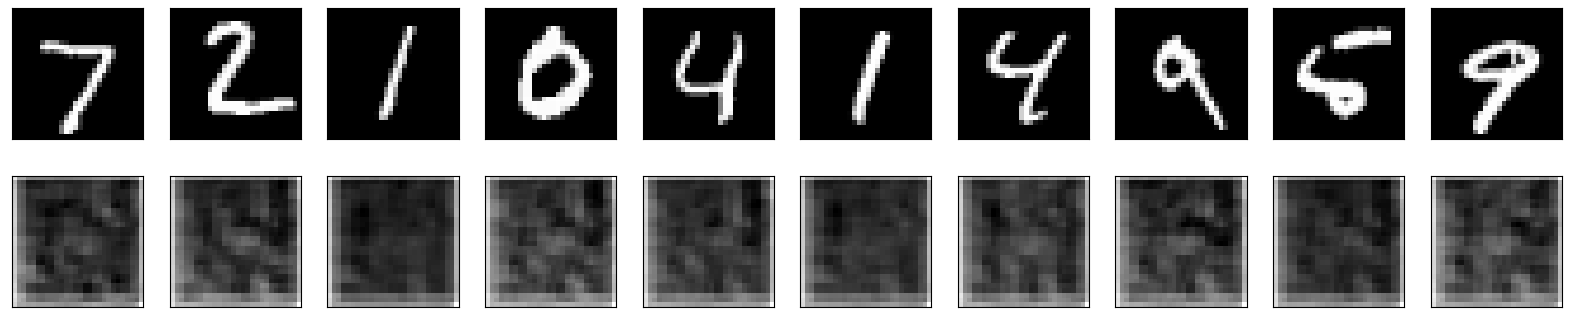

In [5]:
# The first model works, but the reconstruction can still be improved.
# To improve performance, we can train for more epochs and use a slightly larger batch size.

In [ ]:
# Improved experiment:
# - epochs increased from 10 to 20
# - batch size increased from 128 to 138

## Lab Logbook requirement:

1) Copy the autoencoder model and train it with epochs=Z+40,
where your SID is: XXXXXXZ

Use "adam" optimaser.

Leave other parameters the same as in Task 2.

3) Please only add to your Lab Logbook print-screens of:
- Table of your model autoencoder.summary()
- Code of your autoencoder.fit()
- Accuracy detailed graph
- Document the plot of the decoded images for task 2. Change the colour, appearance, and shape of the plot according to your own choice (see plt.figure() parameters).


NOTE: DON'T FORGET TO SAVE AND BACK UP YOUR COMPLETED JUPYTER NOTEBOOK AND LAB LOGBOOK ON GITHUB.

In [ ]:
autoencoder_2 = models.load_model('Conv_autoencoder.keras')
autoencoder_2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history_2 = autoencoder_2.fit(
    x=x_train,
    y=x_train,
    epochs=20,
    batch_size=138,
    shuffle=True,
    verbose=1,
    validation_data=(x_test, x_test)
)

In [ ]:
decoded_imgs_2 = autoencoder_2.predict(x_test)

n = 10

plt.figure(figsize=(20, 4))
for i in range(n):
    # original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # improved reconstructed images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs_2[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()